In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/heart_disease_uci.csv")

In [3]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.shape

(920, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [6]:
df.describe(include="all")

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


In [7]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
trestbps     6.413043
thalch       5.978261
exang        5.978261
chol         3.260870
restecg      0.217391
id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
num          0.000000
dtype: float64

In [9]:
df["num"].value_counts().sort_index()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

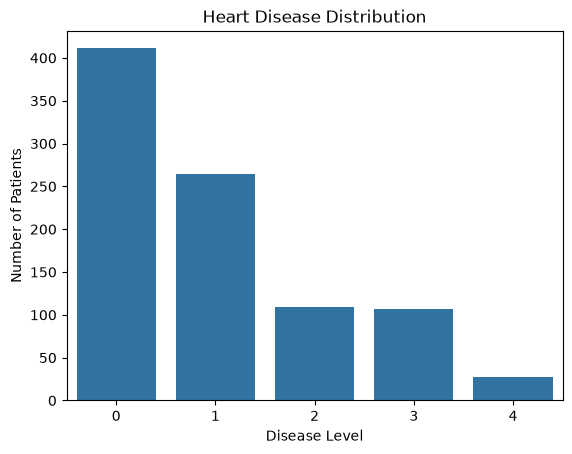

In [10]:
sns.countplot(data=df, x="num")
plt.title("Heart Disease Distribution")
plt.xlabel("Disease Level")
plt.ylabel("Number of Patients")
plt.show()

In [11]:
df["target"] = (df["num"] > 0).astype(int)

In [12]:
df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

In [13]:
df["target"].value_counts(normalize=True)*100

target
1    55.326087
0    44.673913
Name: proportion, dtype: float64

In [14]:
df = df.drop("id", axis=1)

In [25]:
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

In [26]:

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

In [17]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num,target
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652,0.553261
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693,0.497426
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000,1.000000


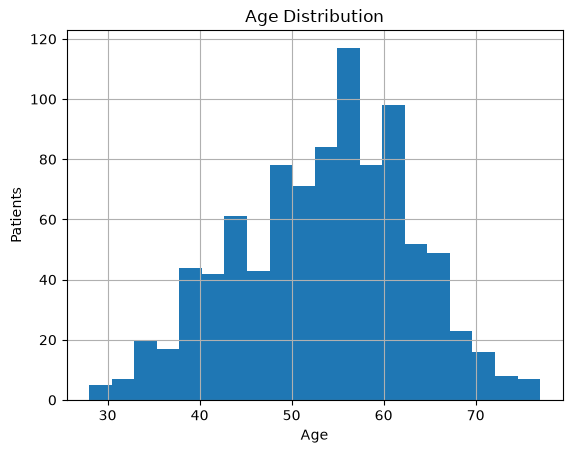

In [18]:
df["age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Patients")
plt.show()

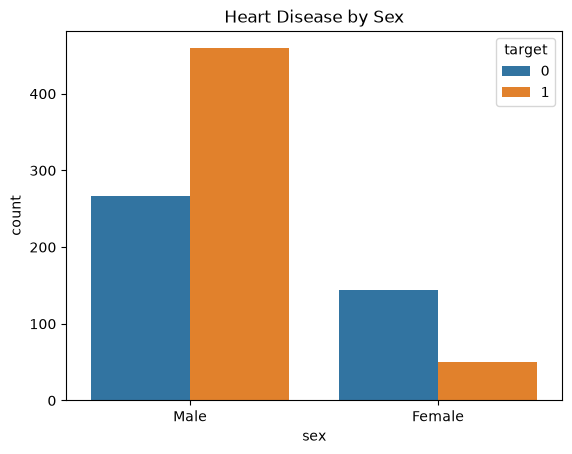

In [19]:
sns.countplot(data=df, x="sex", hue="target")
plt.title("Heart Disease by Sex")
plt.show()

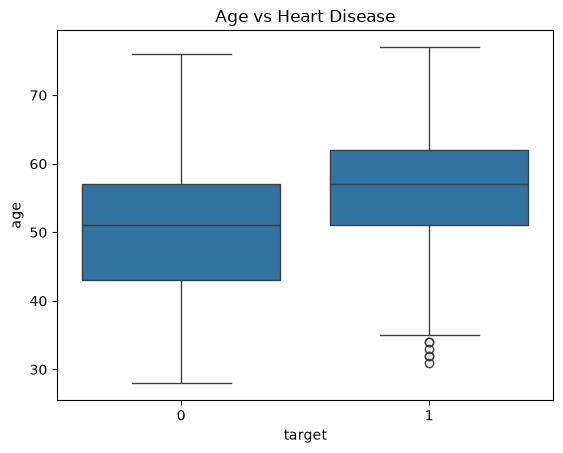

In [20]:
sns.boxplot(data=df, x="target", y="age")
plt.title("Age vs Heart Disease")
plt.show()

In [21]:
print(df["ca"].value_counts(dropna=False))
print("\nSLOPE:")
print(df["slope"].value_counts(dropna=False))
print("\nTHAL:")
print(df["thal"].value_counts(dropna=False))

ca
NaN    611
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64

SLOPE:
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

THAL:
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


In [22]:
pd.crosstab(
    df["sex"],
    df["target"],
    normalize="index"
) * 100

target,0,1
sex,,
Female,74.226804,25.773196
Male,36.776860,63.223140


In [23]:
print("CA")
print(df["ca"].value_counts(dropna=False))

print("\nSLOPE")
print(df["slope"].value_counts(dropna=False))

print("\nTHAL")
print(df["thal"].value_counts(dropna=False))

CA
ca
NaN    611
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64

SLOPE
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

THAL
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


In [24]:
print("\nCA vs TARGET")
print(pd.crosstab(df["ca"], df["target"], normalize="index") * 100)

print("\nSLOPE vs TARGET")
print(pd.crosstab(df["slope"], df["target"], normalize="index") * 100)

print("\nTHAL vs TARGET")
print(pd.crosstab(df["thal"], df["target"], normalize="index") * 100)


CA vs TARGET
target          0          1
ca                          
0.0     73.480663  26.519337
1.0     31.343284  68.656716
2.0     19.512195  80.487805
3.0     15.000000  85.000000

SLOPE vs TARGET
target               0          1
slope                            
downsloping  22.222222  77.777778
flat         22.898551  77.101449
upsloping    61.576355  38.423645

THAL vs TARGET
target                     0          1
thal                                   
fixed defect       23.913043  76.086957
normal             70.408163  29.591837
reversable defect  19.791667  80.208333


In [69]:
# Convert all categorical values to strings
categorical_cols = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

for col in categorical_cols:
    df[col] = df[col].apply(
        lambda x: str(x) if pd.notna(x) else np.nan
    )

In [70]:
X = df.drop("target", axis=1)

y = df["target"]

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (736, 13)
Testing: (184, 13)


In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

In [73]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True
    )),
    ("scaler", StandardScaler())
])

In [74]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [75]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [76]:
from sklearn.linear_model import LogisticRegression

In [77]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [78]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwe

In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8369565217391305
Precision: 0.8333333333333334
Recall   : 0.8823529411764706
F1 Score : 0.8571428571428571
ROC-AUC  : 0.9145145863223338


In [80]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Random Forest Results
---------------------
Accuracy : 0.8369565217391305
Precision: 0.8461538461538461
Recall   : 0.8627450980392157
F1 Score : 0.8543689320388349
ROC-AUC  : 0.9249163079866093


Logistic Regression Confusion Matrix:
[[64 18]
 [12 90]]


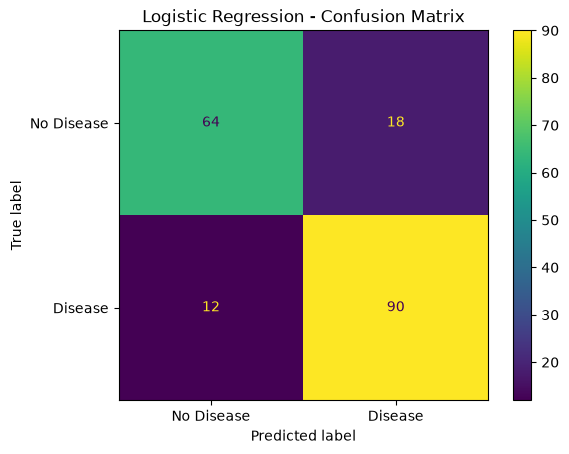

In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred)

print("Logistic Regression Confusion Matrix:")
print(cm_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Disease", "Disease"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Random Forest Confusion Matrix:
[[66 16]
 [14 88]]


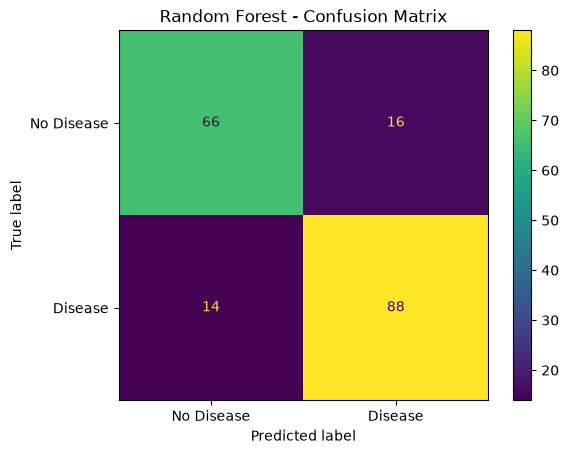

In [82]:
cm_rf = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Disease", "Disease"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Logistic Regression
lr_cv = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Random Forest
rf_cv = cross_validate(
    random_forest,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [84]:
print("Logistic Regression - 5 Fold CV")
print("--------------------------------")

for metric in scoring:
    scores = lr_cv["test_" + metric]
    print(
        metric.upper(),
        ":",
        round(scores.mean(), 4),
        "+/-",
        round(scores.std(), 4)
    )


print("\nRandom Forest - 5 Fold CV")
print("--------------------------")

for metric in scoring:
    scores = rf_cv["test_" + metric]
    print(
        metric.upper(),
        ":",
        round(scores.mean(), 4),
        "+/-",
        round(scores.std(), 4)
    )

Logistic Regression - 5 Fold CV
--------------------------------
ACCURACY : 0.8261 +/- 0.0307
PRECISION : 0.8438 +/- 0.0317
RECALL : 0.8429 +/- 0.0478
F1 : 0.8425 +/- 0.0295
ROC_AUC : 0.9004 +/- 0.0261

Random Forest - 5 Fold CV
--------------------------
ACCURACY : 0.8174 +/- 0.0312
PRECISION : 0.8216 +/- 0.0279
RECALL : 0.8567 +/- 0.0412
F1 : 0.8383 +/- 0.0281
ROC_AUC : 0.8884 +/- 0.021


In [85]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    logistic_model,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__C': 0.1}

Best CV ROC-AUC:
0.8963255935071655


In [86]:
best_lr = grid_search.best_estimator_

tuned_pred = best_lr.predict(X_test)
tuned_prob = best_lr.predict_proba(X_test)[:, 1]

print("Tuned Logistic Regression")
print("-------------------------")
print("Accuracy :", accuracy_score(y_test, tuned_pred))
print("Precision:", precision_score(y_test, tuned_pred))
print("Recall   :", recall_score(y_test, tuned_pred))
print("F1 Score :", f1_score(y_test, tuned_pred))
print("ROC-AUC  :", roc_auc_score(y_test, tuned_prob))

Tuned Logistic Regression
-------------------------
Accuracy : 0.842391304347826
Precision: 0.8288288288288288
Recall   : 0.9019607843137255
F1 Score : 0.863849765258216
ROC-AUC  : 0.9139167862266857


In [87]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__C': 0.1}

Best Cross-Validation ROC-AUC:
0.8963255935071655


In [88]:
tuned_cv = cross_validate(
    best_lr,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned Logistic Regression - 5 Fold CV")
print("-------------------------------------")

for metric in scoring:
    scores = tuned_cv["test_" + metric]
    print(
        metric.upper(),
        ":",
        round(scores.mean(), 4),
        "+/-",
        round(scores.std(), 4)
    )

Tuned Logistic Regression - 5 Fold CV
-------------------------------------
ACCURACY : 0.8283 +/- 0.0261
PRECISION : 0.8458 +/- 0.0273
RECALL : 0.8449 +/- 0.0499
F1 : 0.8443 +/- 0.0263
ROC_AUC : 0.9025 +/- 0.0243


In [89]:
best_lr = grid_search.best_estimator_


feature_names = best_lr.named_steps["preprocessor"].get_feature_names_out()


coefficients = best_lr.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute coefficient
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
13,cat__cp_asymptomatic,0.783369,0.783369
14,cat__cp_atypical angina,-0.612253,0.612253
5,num__ca,0.549739,0.549739
28,cat__slope_flat,0.529764,0.529764
10,num__missingindicator_ca,0.473038,0.473038
33,cat__thal_reversable defect,0.424558,0.424558
12,cat__sex_Male,0.422542,0.422542
11,cat__sex_Female,-0.421236,0.421236
25,cat__exang_True,0.399144,0.399144
23,cat__exang_False,-0.396830,0.396830


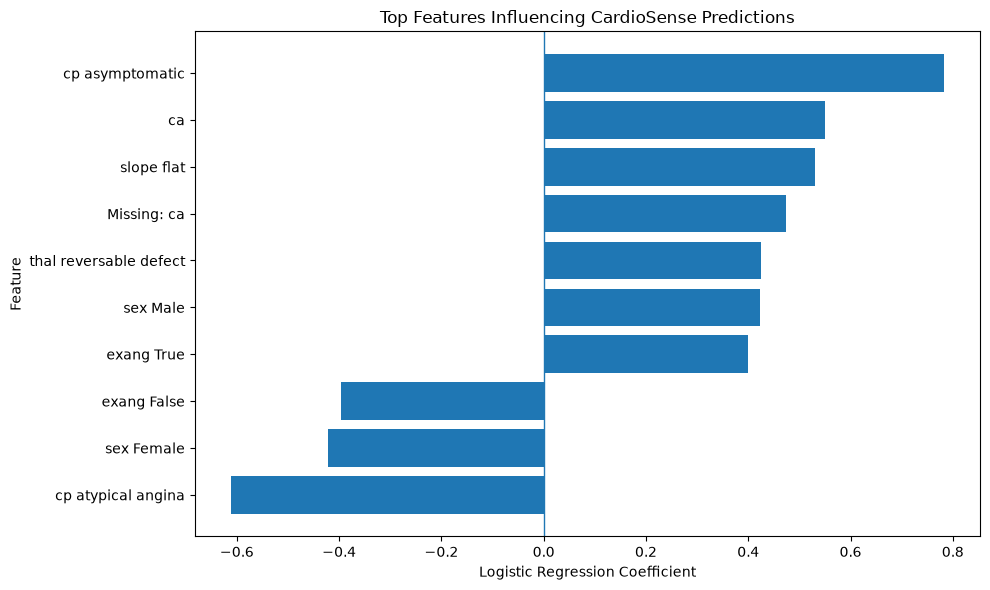

In [90]:
import matplotlib.pyplot as plt


top_features = feature_importance.head(10).copy()


top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("missingindicator_", "Missing: ", regex=False)
    .str.replace("_", " ", regex=False)
)


top_features = top_features.sort_values("Coefficient")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing CardioSense Predictions")

plt.tight_layout()
plt.show()

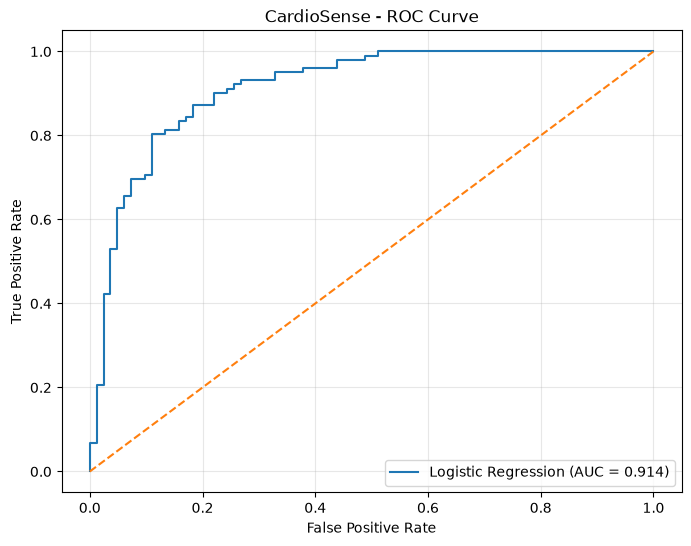

In [91]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# Predictions from our final tuned model
y_prob = best_lr.predict_proba(X_test)[:, 1]

# -------------------------
# ROC CURVE
# -------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CardioSense - ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

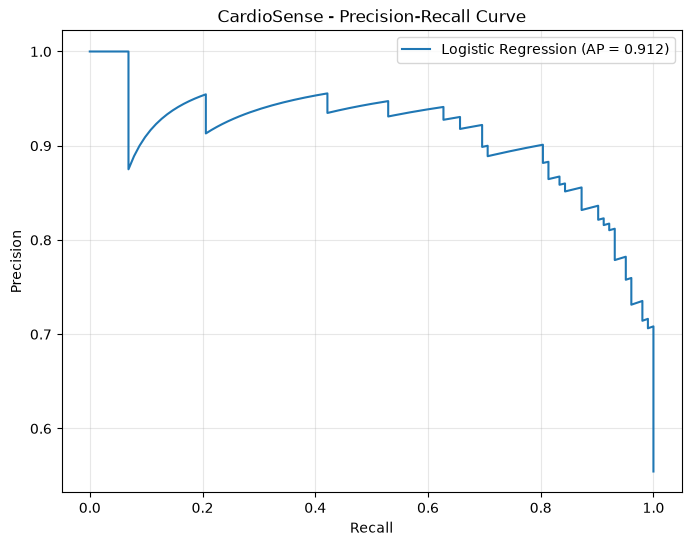

In [92]:
# -------------------------
# PRECISION-RECALL CURVE
# -------------------------

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

average_precision = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CardioSense - Precision-Recall Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [93]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = np.arange(0.30, 0.71, 0.05)

print("Threshold | Precision | Recall | F1")
print("-------------------------------------")

for threshold in thresholds_to_test:

    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(
        f"{threshold:.2f}      | "
        f"{precision:.3f}     | "
        f"{recall:.3f}  | "
        f"{f1:.3f}"
    )

Threshold | Precision | Recall | F1
-------------------------------------
0.30      | 0.764     | 0.951  | 0.847
0.35      | 0.782     | 0.951  | 0.858
0.40      | 0.792     | 0.931  | 0.856
0.45      | 0.810     | 0.922  | 0.862
0.50      | 0.829     | 0.902  | 0.864
0.55      | 0.840     | 0.873  | 0.856
0.60      | 0.865     | 0.814  | 0.838
0.65      | 0.898     | 0.775  | 0.832
0.70      | 0.892     | 0.725  | 0.800


In [95]:
import joblib

joblib.dump(
    best_lr,
    "cardiosense_model.pkl"
)



['cardiosense_model.pkl']

In [96]:

loaded_model = joblib.load("../models/cardiosense_model.pkl")

# Test it on the test data
test_predictions = loaded_model.predict(X_test)
test_probabilities = loaded_model.predict_proba(X_test)[:, 1]

print("Loaded model test accuracy:",
      accuracy_score(y_test, test_predictions))

print("Loaded model test ROC-AUC:",
      roc_auc_score(y_test, test_probabilities))

Loaded model test accuracy: 0.842391304347826
Loaded model test ROC-AUC: 0.9139167862266857


In [97]:
for col in categorical_features:
    print(col)
    print(df[col].unique())
    print()

sex
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

cp
<ArrowStringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str

fbs
<ArrowStringArray>
['True', 'False', nan]
Length: 3, dtype: str

restecg
<ArrowStringArray>
['lv hypertrophy', 'normal', 'st-t abnormality', nan]
Length: 4, dtype: str

exang
<ArrowStringArray>
['False', 'True', nan]
Length: 3, dtype: str

slope
<ArrowStringArray>
['downsloping', 'flat', 'upsloping', nan]
Length: 4, dtype: str

thal
<ArrowStringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str

